<a href="https://colab.research.google.com/github/valentinamondragon/Descarga_genomas_cjejuni_final.ipynb/blob/main/Creaci%C3%B3n%20de%20graficas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Grafica de ST vs numero de genomas --- Tabla de excel

Autor: Valentina Mondragon

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving st_frecuencia.csv to st_frecuencia.csv


In [ ]:
import pandas as pd

df = pd.read_csv("st_frecuencia.csv")

print(df.head())

  ST;FRECUENCIA
0         403;6
1         353;4
2         806;4
3        1244;4
4        4253;4


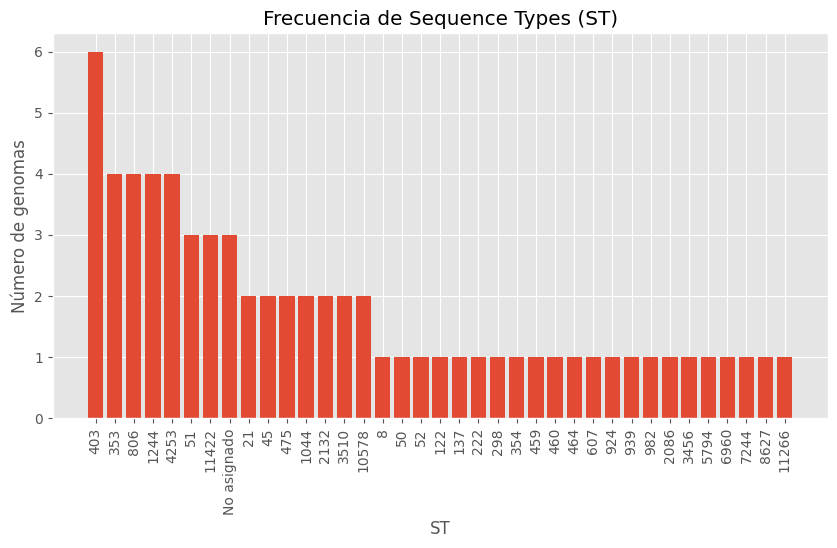

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# estilo tipo ggplot
plt.style.use('ggplot')

# leer archivo CSV separado por ;
df = pd.read_csv("st_frecuencia.csv", sep=";")

# ordenar por frecuencia
df = df.sort_values(by="FRECUENCIA", ascending=False)

# crear figura
plt.figure(figsize=(10,5))

# gráfico de barras
plt.bar(df["ST"].astype(str), df["FRECUENCIA"])

# títulos
plt.title("Frecuencia de Sequence Types (ST)")
plt.xlabel("ST")
plt.ylabel("Número de genomas")

# rotar nombres
plt.xticks(rotation=90)

# mostrar gráfico
plt.show()


Grafica barras horizontales Genomas vs frecuencia%


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving genes_frecuencias.csv to genes_frecuencias.csv


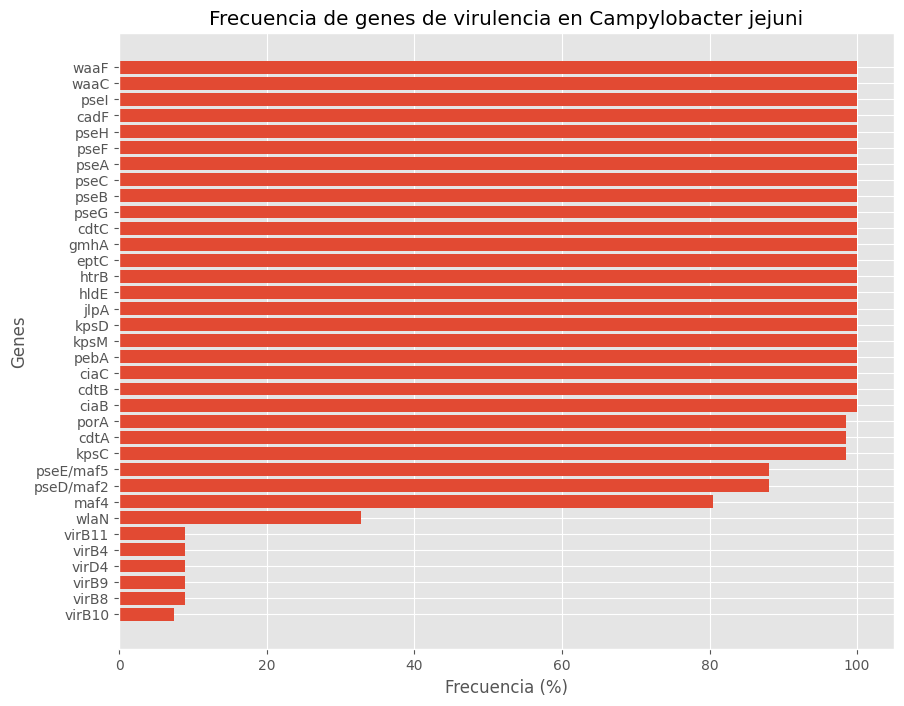

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# estilo gráfico
plt.style.use('ggplot')

# leer archivo CSV
df = pd.read_csv("genes_frecuencias.csv", sep=";")

# convertir porcentajes
df["Frecuencia %"] = df["Frecuencia %"].astype(str).str.replace(",", ".").astype(float)

# ordenar genes
df = df.sort_values(by="Frecuencia %", ascending=True)

# tamaño figura
plt.figure(figsize=(10,8))

# gráfico horizontal
plt.barh(df["Genes"], df["Frecuencia %"])

# títulos
plt.title("Frecuencia de genes de virulencia en Campylobacter jejuni")
plt.xlabel("Frecuencia (%)")
plt.ylabel("Genes")

# mostrar
plt.show()

Creacion Headmap - DISTRIBUCIÓN DE GENES DE VIRULENCIA ENTRE LOS DIFERENTES ST

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heatmap_genes.csv to heatmap_genes (1).csv


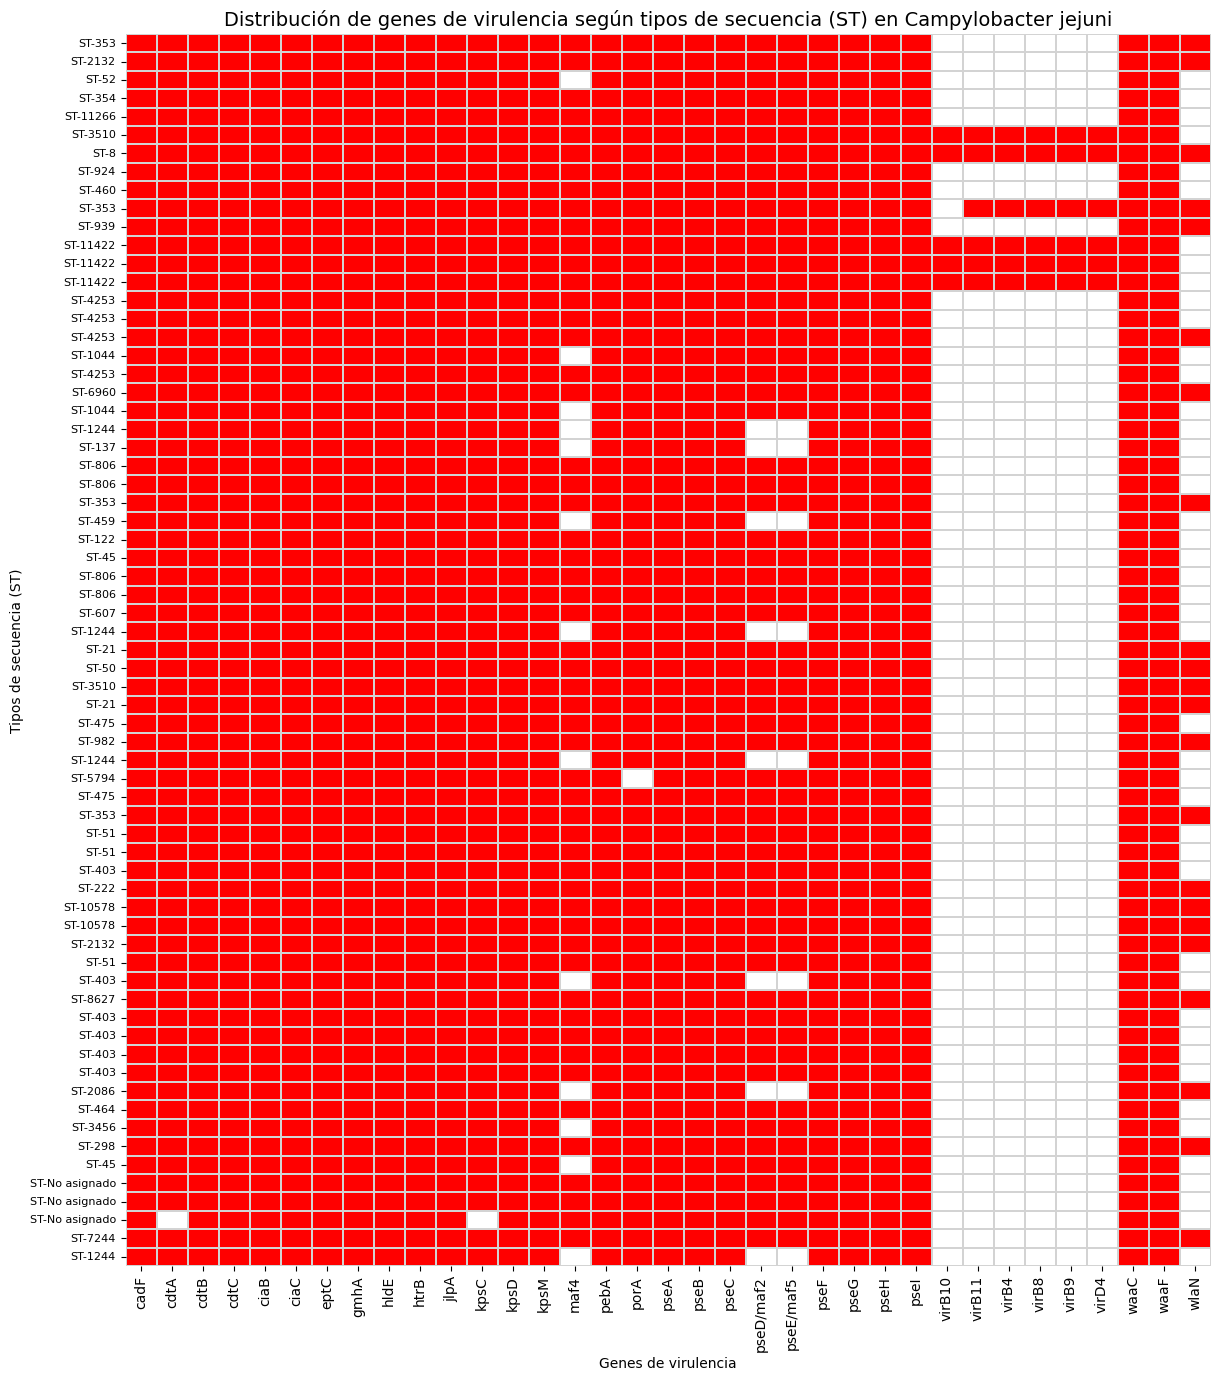

In [ ]:
# ============================================================
# Heatmap de genes de virulencia y tipos de secuencia (ST)
# Campylobacter jejuni
# ------------------------------------------------------------
# Este script genera un heatmap binario de presencia/ausencia
# de genes de virulencia identificados mediante ABRicate.
#
# El eje Y muestra los tipos de secuencia (ST)
# asociados a cada genoma analizado.
#
# Archivo de entrada:
#   heatmap_genes (1).csv
#
# Formato esperado:
# - Archivo separado por ";"
# - Columna "Genomas"
# - Columna "ST"
# - Genes codificados como:
#       1 = presencia
#       vacío = ausencia
#
# Librerías:
#   pandas
#   matplotlib
#   seaborn
#
# Autor: Valentina Mondragón
# ============================================================


# =====================
# Importar librerías
# =====================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap


# =====================
# Leer archivo CSV
# =====================

df = pd.read_csv("heatmap_genes (1).csv", sep=";")


# =====================
# Preparar datos
# =====================

# Crear etiquetas utilizando únicamente los ST
df["Label"] = "ST-" + df["ST"].astype(str)

# Usar ST como índice del heatmap
df = df.set_index("Label")

# Eliminar columnas que no se usarán
df = df.drop(columns=["Genomas", "ST"])

# Reemplazar valores vacíos por 0
df = df.fillna(0)

# Convertir todos los datos a enteros
df = df.astype(int)


# =====================
# Definir colores
# =====================

# blanco = ausencia
# rojo = presencia
cmap = ListedColormap(["white", "red"])


# =====================
# Crear figura
# =====================

plt.figure(figsize=(14,16))

# Generar heatmap
sns.heatmap(
    df,
    cmap=cmap,
    cbar=False,
    linewidths=0.2,
    linecolor="lightgray"
)


# =====================
# Personalizar gráfico
# =====================

plt.title(
    "Distribución de genes de virulencia según tipos de secuencia (ST) en Campylobacter jejuni",
    fontsize=14
)

plt.xlabel("Genes de virulencia")
plt.ylabel("Tipos de secuencia (ST)")

# Rotar nombres de genes
plt.xticks(rotation=90)


# =====================
# Mostrar figura
# =====================

plt.yticks(fontsize=8)

plt.show()